# Notebook 4. Probability of Default Modelling

## Objective

This notebook develops the Probability of Default (PD) module of the credit risk framework built on the Lending Club retail loan portfolio.

The objective is not to approach default prediction as a standalone machine learning task, but as the core predictive component of a broader risk modelling workflow inspired by IFRS 9.

Within that framework, PD is the first key input required to estimate expected credit losses through the relationship:

ECL = PD × LGD × EAD

This notebook reuses the analytical dataset prepared in previous steps, applies a structured modelling pipeline, and compares a small and purposeful set of models:

- Logistic Regression
- Random Forest
- XGBoost

The focus is on building a model that is not only predictive, but also interpretable, stable and reusable for downstream tasks such as staging, ECL computation and stress testing.

The final output is a scored portfolio with estimated PD at loan level, along with model artifacts and evaluation metrics.

## 1. Imports and configuration

We start by importing the required libraries, setting global configurations and defining reproducibility parameters.

In [7]:
# Standard libraries
import json
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

# Model persistence
import joblib

# Config
warnings.filterwarnings("ignore")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")

## 2. Load analytical dataset and feature configuration

We load the model-ready dataset produced in Notebook 3, along with the feature configuration file.

In [8]:
# Paths
CURRENT_PATH = Path.cwd().resolve()

if CURRENT_PATH.name == "notebooks":
    BASE_PATH = CURRENT_PATH.parent
else:
    BASE_PATH = CURRENT_PATH

DATA_PATH = BASE_PATH / "data" / "processed"

dataset_path = DATA_PATH / "lending_club_model_dataset.parquet"
config_path = DATA_PATH / "model_features_config.json"

print("BASE_PATH:", BASE_PATH)
print("Dataset path exists:", dataset_path.exists())
print("Config path exists:", config_path.exists())

# Load data
df = pd.read_parquet(dataset_path)

# Load feature config
with open(config_path, "r") as f:
    feature_config = json.load(f)

df.shape

BASE_PATH: /home/apalo/Credit-Risk-Ifrs9
Dataset path exists: True
Config path exists: True


(581969, 109)

## 3. Define target and feature space

We define the target variable and retrieve the list of candidate predictors from the configuration file generated in Notebook 3.

This ensures consistency across the pipeline and avoids redefining variables manually.

In [9]:
target = "default_flag"

numerical_features = feature_config["numerical_features"]
categorical_features = feature_config["categorical_features"]

features = numerical_features + categorical_features

print("Total features:", len(features))
print("Numerical:", len(numerical_features))
print("Categorical:", len(categorical_features))

Total features: 99
Numerical: 84
Categorical: 15


## 4. Basic validation checks

Before modelling, we perform basic checks to ensure that:

- all required columns are present
- the target variable is correctly defined
- the dataset structure matches expectations

In [10]:
# Check columns
missing_cols = [col for col in features + [target] if col not in df.columns]

print("Missing columns:", missing_cols)

# Target distribution
df[target].value_counts(normalize=True)

Missing columns: []


default_flag
0    0.773727
1    0.226273
Name: proportion, dtype: float64

## 5. Train-test split (temporal)

A temporal split is used instead of a random split.

The model is trained on earlier loan originations and evaluated on more recent ones. This approach better reflects real-world deployment, where models are applied to future data.

The variable `issue_d_date` is used for ordering, but not as a predictor.

In [11]:
# Ensure date format
df["issue_d_date"] = pd.to_datetime(df["issue_d_date"])

# Sort by time
df = df.sort_values("issue_d_date")

# Split index
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (465575, 99)
Test size: (116394, 99)


## 6. Preprocessing pipeline

We construct a preprocessing architecture using:

- numerical pipeline: imputation + scaling
- categorical pipeline: imputation + one-hot encoding

This structure ensures reproducibility and compatibility across models.

In [12]:
# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Column transformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

## 7. Model setup

We define three models representing different levels of complexity:

- Logistic Regression: interpretable baseline
- Random Forest: non-linear ensemble
- XGBoost: high-performance gradient boosting model

No extensive hyperparameter tuning is performed to keep the framework simple and reproducible.

In [13]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

models = {
    "logistic": log_model,
    "random_forest": rf_model,
    "xgboost": xgb_model
}

## 8. Data quality check before training

### 8.1 Identification of invalid numerical values

We check whether numerical features contain infinite values generated by ratio-based transformations.

Such values typically arise when denominators are zero or extremely small, and must be handled before model training.

In [14]:
# Check infinite values in numerical features
inf_counts = (
    X_train[numerical_features]
    .replace([np.inf, -np.inf], np.nan)
    .isna()
    .sum()
    .sort_values(ascending=False)
)

# Compare original NaN counts vs NaN+inf counts
original_nan_counts = X_train[numerical_features].isna().sum()

inf_only_counts = (inf_counts - original_nan_counts).sort_values(ascending=False)

inf_problem_features = inf_only_counts[inf_only_counts > 0]

print("Numerical features with inf or -inf values:")
display(inf_problem_features.head(20))

Numerical features with inf or -inf values:


loan_to_income           23
installment_to_income    23
dtype: int64

### 8.2 Numerical sanitisation

Infinite values are converted into missing values before applying the preprocessing pipeline.

This approach preserves the structure of the dataset while allowing the imputation step to handle these observations consistently.

In [15]:
# Create safe copies
X_train = X_train.copy()
X_test = X_test.copy()

# Replace inf values with NaN
X_train[numerical_features] = X_train[numerical_features].replace([np.inf, -np.inf], np.nan)
X_test[numerical_features] = X_test[numerical_features].replace([np.inf, -np.inf], np.nan)

In [16]:
train_inf_total = np.isinf(X_train[numerical_features].to_numpy()).sum()
test_inf_total = np.isinf(X_test[numerical_features].to_numpy()).sum()

print("Remaining inf values in X_train:", train_inf_total)
print("Remaining inf values in X_test:", test_inf_total)

Remaining inf values in X_train: 0
Remaining inf values in X_test: 0


### 8.3 Model training

The candidate models are trained separately to keep execution manageable and to reduce the risk of losing progress in a large notebook environment.

This also makes the workflow easier to monitor, compare and debug.

In [17]:
trained_models = {}

#### 8.3.1 Logistic Regression

In [18]:
print("Training logistic regression...")

log_model.fit(X_train, y_train)
trained_models["logistic"] = log_model

print("Logistic regression trained successfully.")

Training logistic regression...
Logistic regression trained successfully.


#### 8.3.2 Random Forest

In [19]:
print("Training random forest...")

rf_model.fit(X_train, y_train)
trained_models["random_forest"] = rf_model

print("Random forest trained successfully.")

Training random forest...
Random forest trained successfully.


#### 8.3.3 XGBoost

In [20]:
print("Training XGBoost...")

xgb_model.fit(X_train, y_train)
trained_models["xgboost"] = xgb_model

print("XGBoost trained successfully.")

Training XGBoost...
XGBoost trained successfully.


## 9. Model evaluation

The models are evaluated on the test set along two key dimensions:

- discrimination: the ability to correctly rank borrowers by risk
- calibration: the accuracy of predicted probabilities

Both aspects are essential in credit risk modelling.

In [21]:
results = []

for name, model in trained_models.items():
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_pred_proba)
    
    results.append({
        "model": name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "brier_score": brier
    })

results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
results_df

,model,roc_auc,pr_auc,precision,recall,f1,brier_score
2,xgboost,0.964764,0.932268,0.936018,0.791204,0.857540,0.057290
0,logistic,0.957715,0.918410,0.943868,0.735741,0.826910,0.064121
1,random_forest,0.955587,0.919409,0.935108,0.790916,0.856989,0.062043


### 9.1 Discrimination analysis

We compare the models using ROC and Precision-Recall curves.

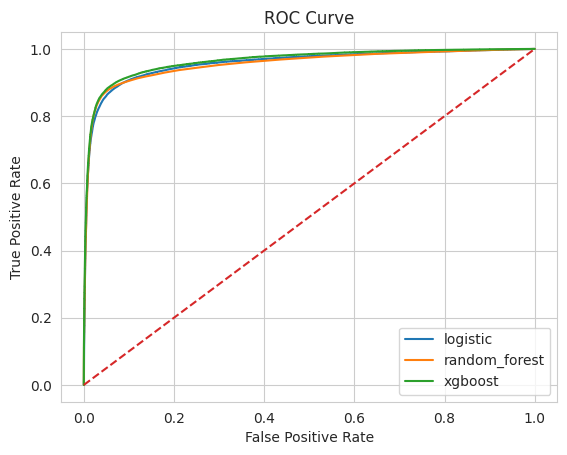

In [22]:
plt.figure()

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

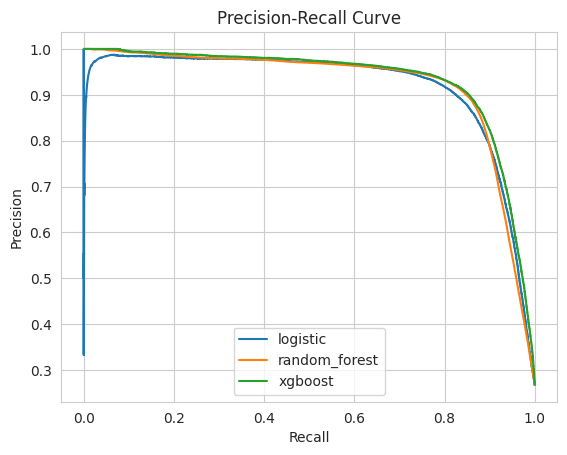

In [23]:
plt.figure()

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    plt.plot(recall_vals, precision_vals, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

### 9.2 Calibration analysis

We evaluate how well predicted probabilities align with observed default rates.

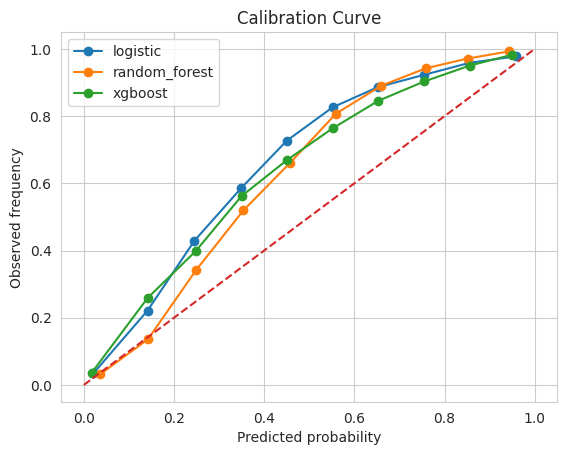

In [24]:
plt.figure()

for name, model in trained_models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## 10. Champion model selection

The final model is selected considering:

- discrimination performance (ROC AUC, PR AUC)
- calibration quality (Brier score, calibration curve)
- interpretability and stability

The objective is not only to maximize predictive performance, but to select a model suitable for a credit risk framework.

In [25]:
results_df

,model,roc_auc,pr_auc,precision,recall,f1,brier_score
2,xgboost,0.964764,0.932268,0.936018,0.791204,0.857540,0.057290
0,logistic,0.957715,0.918410,0.943868,0.735741,0.826910,0.064121
1,random_forest,0.955587,0.919409,0.935108,0.790916,0.856989,0.062043


All three models show strong predictive performance, with ROC AUC values above 0.95, indicating excellent discrimination.

XGBoost slightly outperforms the other models across all key metrics:

- highest ROC AUC and PR AUC
- better balance between precision and recall
- lowest Brier score, indicating improved probability calibration

Logistic Regression remains highly competitive and provides strong interpretability, with well-behaved calibration, although it shows lower recall and slightly weaker overall performance.

Random Forest performs similarly to XGBoost in some metrics but does not offer a clear advantage in either discrimination or calibration.

The performance differences between models are moderate, which is common in structured credit risk datasets. In this context, model selection is not only driven by predictive accuracy, but by the balance between discrimination and calibration.

Based on these results, XGBoost is selected as the champion model for PD estimation, as it provides the best overall trade-off between predictive performance and probability accuracy.



In [26]:
#For later use, we will save the champion model to disk
champion_model_name = "xgboost"
champion_model = trained_models[champion_model_name]

## 11. Model interpretation

Although XGBoost is selected as the champion model, it is still useful to examine the main risk drivers across different model families.

This section provides:

- coefficient-based interpretation for Logistic Regression
- feature importance for Random Forest
- feature importance for XGBoost

The objective is to understand the variables that appear to be most relevant in the estimation of default risk.

In [27]:
# Retrieve transformed feature names from the fitted preprocessor
fitted_preprocessor = trained_models["logistic"].named_steps["preprocessor"]
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of transformed features:", len(transformed_feature_names))
print(transformed_feature_names[:10])

Number of transformed features: 233
['num__loan_amnt' 'num__funded_amnt' 'num__funded_amnt_inv'
 'num__int_rate' 'num__installment' 'num__annual_inc' 'num__dti'
 'num__delinq_2yrs' 'num__fico_range_low' 'num__fico_range_high']


### 11.1 Logistic Regression coefficients

Logistic Regression provides a transparent baseline. Positive coefficients are associated with higher default risk, while negative coefficients are associated with lower default risk.

In [28]:
log_coefficients = trained_models["logistic"].named_steps["model"].coef_[0]

log_coef_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "coefficient": log_coefficients,
    "abs_coefficient": np.abs(log_coefficients)
}).sort_values("abs_coefficient", ascending=False)

log_coef_df.head(20)

,feature,coefficient,abs_coefficient
217,cat__debt_settlement_flag_Y,4.382248,4.382248
216,cat__debt_settlement_flag_N,-4.166856,4.166856
18,num__last_fico_range_high,-2.940048,2.940048
82,num__term_months,0.435539,0.435539
157,cat__purpose_small_business,0.399614,0.399614
4,num__installment,0.332749,0.332749
195,cat__addr_state_OK,0.257973,0.257973
85,cat__term_ 60 months,0.238406,0.238406
212,cat__application_type_Individual,0.215799,0.215799
218,"cat__income_band_(-0.001, 42000.0]",0.194060,0.194060


In [29]:
top_positive_log = log_coef_df.sort_values("coefficient", ascending=False).head(10)
top_negative_log = log_coef_df.sort_values("coefficient", ascending=True).head(10)

print("Top positive coefficients")
display(top_positive_log[["feature", "coefficient"]])

print("Top negative coefficients")
display(top_negative_log[["feature", "coefficient"]])

Top positive coefficients


,feature,coefficient
217,cat__debt_settlement_flag_Y,4.382248
82,num__term_months,0.435539
157,cat__purpose_small_business,0.399614
4,num__installment,0.332749
195,cat__addr_state_OK,0.257973
85,cat__term_ 60 months,0.238406
212,cat__application_type_Individual,0.215799
218,"cat__income_band_(-0.001, 42000.0]",0.194060
19,num__last_fico_range_low,0.184843
229,"cat__loan_amnt_band_(15000.0, 21875.0]",0.176453


Top negative coefficients


,feature,coefficient
216,cat__debt_settlement_flag_N,-4.166856
18,num__last_fico_range_high,-2.940048
206,cat__addr_state_WA,-0.178199
232,"cat__loan_amnt_band_(999.999, 6600.0]",-0.168041
92,cat__grade_G,-0.164522
151,cat__purpose_house,-0.162126
196,cat__addr_state_OR,-0.150949
25,num__tot_cur_bal,-0.148001
199,cat__addr_state_SC,-0.139918
64,num__num_rev_tl_bal_gt_0,-0.137680


### 11.2 Tree-based feature importance

For Random Forest and XGBoost, feature importance provides a high-level view of which transformed variables contribute most to model decisions.

These importance measures are useful for interpretation, although they should be read more cautiously than logistic coefficients.

In [30]:
rf_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": trained_models["random_forest"].named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance_df = pd.DataFrame({
    "feature": transformed_feature_names,
    "importance": trained_models["xgboost"].named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("Top Random Forest feature importances")
display(rf_importance_df.head(15))

print("Top XGBoost feature importances")
display(xgb_importance_df.head(15))

Top Random Forest feature importances


,feature,importance
18,num__last_fico_range_high,0.267888
19,num__last_fico_range_low,0.216224
216,cat__debt_settlement_flag_N,0.039702
217,cat__debt_settlement_flag_Y,0.035935
3,num__int_rate,0.015368
82,num__term_months,0.009761
80,num__loan_to_income,0.009549
6,num__dti,0.009384
81,num__installment_to_income,0.008690
42,num__avg_cur_bal,0.007887


Top XGBoost feature importances


,feature,importance
19,num__last_fico_range_low,0.422329
18,num__last_fico_range_high,0.139502
217,cat__debt_settlement_flag_Y,0.090490
216,cat__debt_settlement_flag_N,0.057855
84,cat__term_ 36 months,0.029795
82,num__term_months,0.024495
31,num__total_bal_il,0.010495
2,num__funded_amnt_inv,0.009706
0,num__loan_amnt,0.009326
80,num__loan_to_income,0.007751


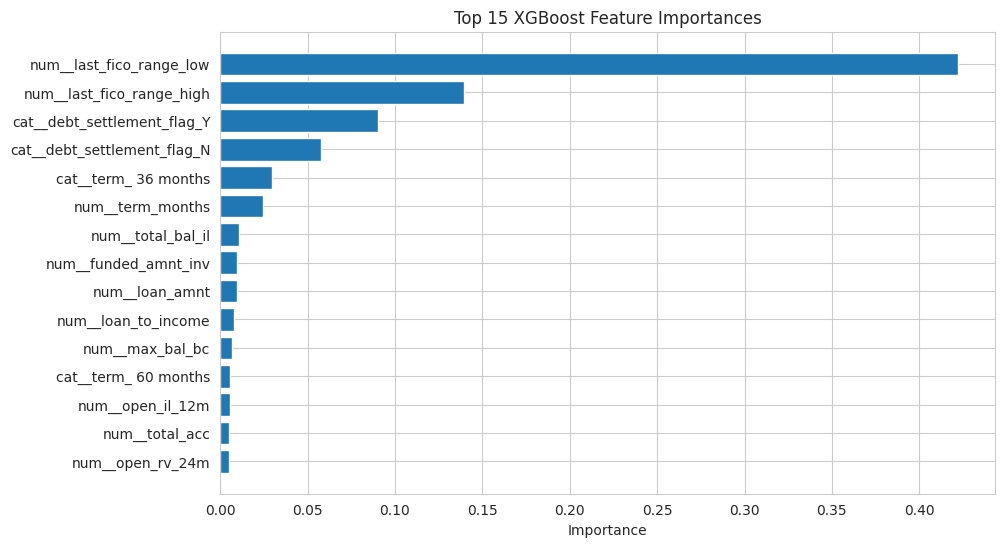

In [31]:
plt.figure(figsize=(10, 6))
plt.barh(
    xgb_importance_df.head(15).sort_values("importance")["feature"],
    xgb_importance_df.head(15).sort_values("importance")["importance"]
)
plt.xlabel("Importance")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

## 12. Score the full portfolio

The champion model is now applied to the full analytical dataset in order to generate loan-level estimated PD.

This scored dataset will become the PD layer used in the following stages of the framework.

In [32]:
X_full = df[features].copy()
X_full[numerical_features] = X_full[numerical_features].replace([np.inf, -np.inf], np.nan)

df_pd = df.copy()
df_pd["pd_estimated"] = champion_model.predict_proba(X_full)[:, 1]

df_pd[["default_flag", "pd_estimated"]].head()

,default_flag,pd_estimated
355318,0,0.009550
355289,0,0.001774
355290,0,0.002879
355291,0,0.027375
355292,0,0.016306


## 13. Risk buckets

To evaluate the practical ordering power of the champion model, the scored portfolio is grouped into risk buckets based on estimated PD.

For each bucket, we compare:

- number of loans
- average predicted PD
- observed default rate

A well-ranked model should show a clear monotonic increase in observed default rates across higher-risk buckets.

In [33]:
df_pd["risk_bucket"] = pd.qcut(
    df_pd["pd_estimated"],
    q=10,
    labels=[f"Decile_{i}" for i in range(1, 11)],
    duplicates="drop"
)

risk_bucket_table = (
    df_pd.groupby("risk_bucket", observed=False)
    .agg(
        n_loans=("default_flag", "size"),
        avg_pd_estimated=("pd_estimated", "mean"),
        observed_default_rate=("default_flag", "mean")
    )
    .reset_index()
)

risk_bucket_table

,risk_bucket,n_loans,avg_pd_estimated,observed_default_rate
0,Decile_1,58197,0.002614,0.001564
1,Decile_2,58197,0.004139,0.002681
2,Decile_3,58197,0.006001,0.005791
3,Decile_4,58197,0.008629,0.009330
4,Decile_5,58197,0.013048,0.015516
5,Decile_6,58196,0.022947,0.029865
6,Decile_7,58197,0.067273,0.082977
7,Decile_8,58197,0.351142,0.370638
8,Decile_9,58197,0.750206,0.783271
9,Decile_10,58197,0.945378,0.961098


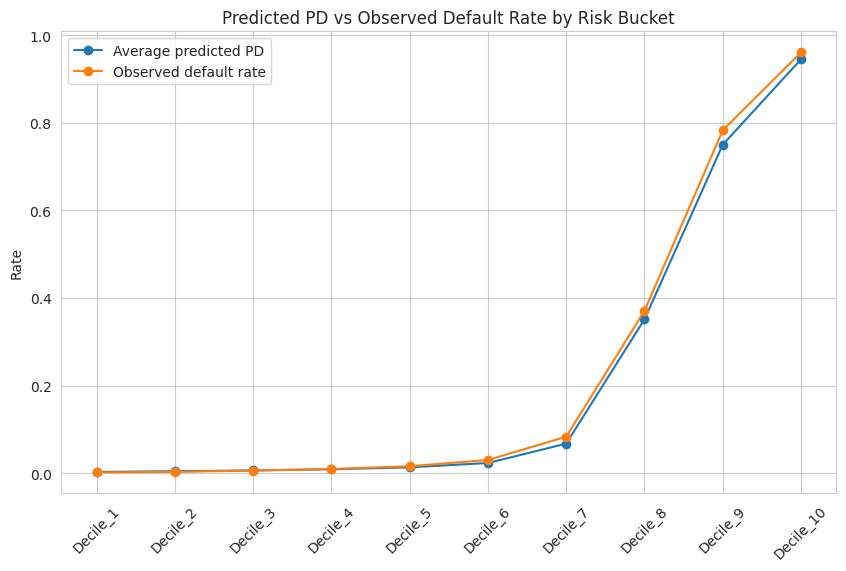

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(risk_bucket_table["risk_bucket"], risk_bucket_table["avg_pd_estimated"], marker="o", label="Average predicted PD")
plt.plot(risk_bucket_table["risk_bucket"], risk_bucket_table["observed_default_rate"], marker="o", label="Observed default rate")
plt.xticks(rotation=45)
plt.ylabel("Rate")
plt.title("Predicted PD vs Observed Default Rate by Risk Bucket")
plt.legend()
plt.show()

## 14. Segment analysis

As a light portfolio reading exercise, we examine how estimated PD varies across a small number of interpretable portfolio segments.

The goal is not to create a full segmentation report here, but to show how the PD layer can already support a first risk reading of the portfolio.

### 14.1 PD by grade

In [35]:
pd_by_grade = (
    df_pd.groupby("grade", observed=False)
    .agg(
        n_loans=("default_flag", "size"),
        avg_pd_estimated=("pd_estimated", "mean"),
        observed_default_rate=("default_flag", "mean")
    )
    .reset_index()
    .sort_values("grade")
)

pd_by_grade

,grade,n_loans,avg_pd_estimated,observed_default_rate
0,A,108330,0.064293,0.067534
1,B,163523,0.145537,0.153972
2,C,168095,0.244313,0.255564
3,D,83431,0.337177,0.350553
4,E,41476,0.423759,0.434251
5,F,12842,0.505583,0.514873
6,G,4272,0.546956,0.552669


### 14.2 PD by income band

In [36]:
pd_by_income_band = (
    df_pd.groupby("income_band", observed=False)
    .agg(
        n_loans=("default_flag", "size"),
        avg_pd_estimated=("pd_estimated", "mean"),
        observed_default_rate=("default_flag", "mean")
    )
    .reset_index()
)

pd_by_income_band

,income_band,n_loans,avg_pd_estimated,observed_default_rate
0,"(-0.001, 42000.0]",119816,0.250503,0.262494
1,"(100000.0, 10999200.0]",110876,0.171952,0.180589
2,"(42000.0, 57000.0]",114603,0.235669,0.244121
3,"(57000.0, 75000.0]",129112,0.220486,0.229646
4,"(75000.0, 100000.0]",107562,0.202787,0.209953


### 14.3 PD by term

In [37]:
pd_by_term = (
    df_pd.groupby("term_months", observed=False)
    .agg(
        n_loans=("default_flag", "size"),
        avg_pd_estimated=("pd_estimated", "mean"),
        observed_default_rate=("default_flag", "mean")
    )
    .reset_index()
    .sort_values("term_months")
)

pd_by_term

,term_months,n_loans,avg_pd_estimated,observed_default_rate
0,36,439529,0.169530,0.178512
1,60,142440,0.364043,0.373652


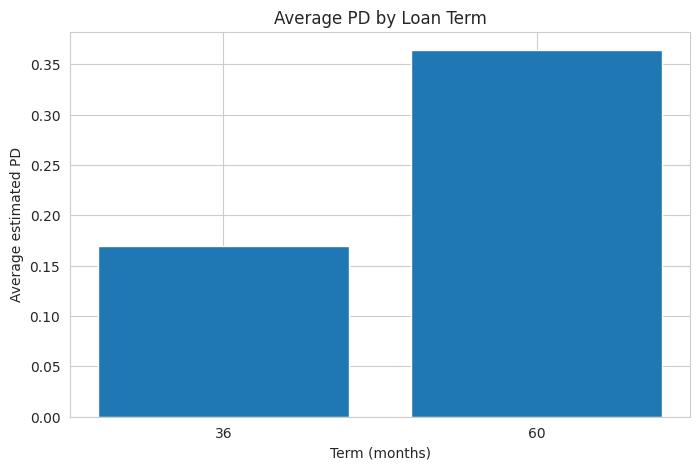

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(pd_by_term["term_months"].astype(str), pd_by_term["avg_pd_estimated"])
plt.xlabel("Term (months)")
plt.ylabel("Average estimated PD")
plt.title("Average PD by Loan Term")
plt.show()

## 15. Monte Carlo simulation of defaults

This section is a brief exploratory extension and does not form part of the core PD modelling workflow.

Using the estimated PD as loan-level default probability, we simulate portfolio defaults under a simple Bernoulli framework in order to observe the distribution of aggregate defaults.

A naive Monte Carlo implementation using full matrix replication can easily lead to memory issues in large portfolios. The simulation was therefore implemented iteratively to ensure scalability and stability.

In [39]:
n_simulations = 1000
pd_values = df_pd["pd_estimated"].to_numpy()

portfolio_default_counts = np.array([
    np.random.binomial(n=1, p=pd_values).sum()
    for _ in range(n_simulations)
])

pd.Series(portfolio_default_counts).describe()

count      1000.000000
mean     126364.458000
std         181.762041
min      125768.000000
25%      126240.750000
50%      126364.000000
75%      126488.000000
max      126972.000000
dtype: float64

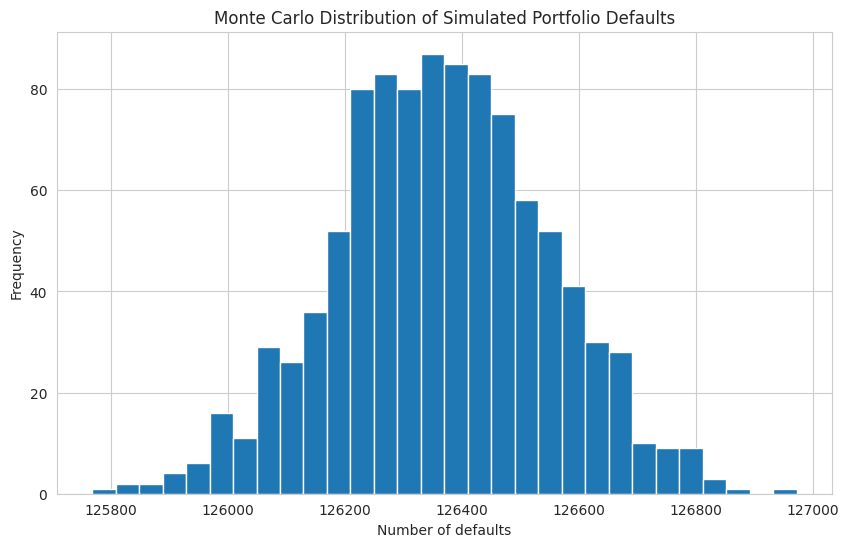

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(portfolio_default_counts, bins=30)
plt.xlabel("Number of defaults")
plt.ylabel("Frequency")
plt.title("Monte Carlo Distribution of Simulated Portfolio Defaults")
plt.show()

## 16. Save reusable outputs

The final step is to persist the main artifacts generated in this notebook so that the following notebooks can directly reuse the PD layer.

The key outputs are:

- full scored dataset with estimated PD
- model evaluation metrics
- champion model artifact
- risk bucket summary table

In [41]:
# Output paths
processed_path = BASE_PATH / "data" / "processed"
models_path = BASE_PATH / "models"

processed_path.mkdir(parents=True, exist_ok=True)
models_path.mkdir(parents=True, exist_ok=True)

In [42]:
# Add model metadata
df_pd["pd_model_name"] = champion_model_name

In [43]:
# Save scored dataset
df_pd.to_parquet(processed_path / "lending_club_pd.parquet", index=False)

# Save metrics
metrics_payload = {
    "champion_model": champion_model_name,
    "evaluation_results": results_df.to_dict(orient="records")
}

with open(processed_path / "pd_model_metrics.json", "w") as f:
    json.dump(metrics_payload, f, indent=4)

# Save champion model
joblib.dump(champion_model, models_path / "pd_champion_model.joblib")

# Save risk buckets
risk_bucket_table.to_csv(processed_path / "pd_risk_buckets.csv", index=False)

In [45]:
# Create dataset for Power BI
from pathlib import Path

powerbi_path = Path("../data/powerbi")
powerbi_path.mkdir(parents=True, exist_ok=True)

powerbi_columns = [
    "loan_amnt",
    "term_months",
    "grade",
    "income_band",
    "fico_band",
    "pd_estimated",
    "default_flag",
    "risk_bucket"
]

df_powerbi = df_pd[powerbi_columns].copy()

df_powerbi.to_csv(
    powerbi_path / "lending_club_pd_powerbi.csv",
    index=False
)

df_powerbi.head()

,loan_amnt,term_months,grade,income_band,fico_band,pd_estimated,default_flag,risk_bucket
355318,16675.0,36,C,"(-0.001, 42000.0]","(682.0, 697.0]",0.009550,0,Decile_4
355289,8400.0,36,A,"(75000.0, 100000.0]","(697.0, 722.0]",0.001774,0,Decile_1
355290,35000.0,60,D,"(75000.0, 100000.0]","(661.999, 672.0]",0.002879,0,Decile_1
355291,14000.0,60,D,"(100000.0, 10999200.0]","(661.999, 672.0]",0.027375,0,Decile_6
355292,5000.0,36,B,"(42000.0, 57000.0]","(697.0, 722.0]",0.016306,0,Decile_5


## 17. Final conclusions

This notebook developed and validated a Probability of Default (PD) modelling framework using a retail lending portfolio inspired by IFRS 9 principles. The objective was not only to build a predictive model, but to construct a structured, interpretable and reproducible risk modelling pipeline aligned with real-world credit risk practices.

### Model performance

All three models evaluated (Logistic Regression, Random Forest and XGBoost) show strong predictive performance:

* ROC AUC above 0.95 across all models, indicating excellent discrimination
* High PR AUC values, confirming robustness under class imbalance
* Consistent precision–recall trade-offs

XGBoost achieves the best overall performance:

* Highest ROC AUC (0.9648)
* Highest PR AUC (0.9323)
* Best F1 score
* Lowest Brier score (0.0573), indicating superior calibration

However, Logistic Regression remains highly competitive and provides strong interpretability, which is critical in regulated environments.

### Discrimination vs calibration

The evaluation explicitly separates two key dimensions:

Discrimination
The ability to correctly rank borrowers by risk is very strong across all models. ROC and PR curves confirm that the model effectively distinguishes between defaulting and non-defaulting loans.

Calibration
Calibration results show that predicted probabilities closely match observed default rates across risk buckets:

* The calibration curve is close to the diagonal
* Brier scores are low
* Decile analysis shows strong alignment between predicted PD and observed default rates

This is especially relevant for IFRS 9, where accurate probability estimation is as important as ranking.

### Risk segmentation

The segmentation analysis confirms that the model captures economically meaningful patterns:

* PD increases monotonically across risk deciles
* Higher loan grades (E–G) exhibit significantly higher default rates
* Lower income bands show higher risk levels
* Longer loan terms (60 months) are associated with substantially higher PD

These results validate that the model is consistent with credit risk intuition and portfolio behaviour.

### Model interpretability

Feature importance analysis across models highlights consistent drivers of credit risk:

* FICO score variables are the most influential predictors
* Debt settlement indicators strongly increase default probability
* Loan term and leverage-related variables (DTI, loan-to-income) play a relevant role

Logistic regression coefficients provide clear directional interpretation, while tree-based models confirm non-linear effects and interactions.

### Champion model selection

XGBoost is selected as the champion model based on:

* Superior discrimination performance
* Better calibration (lowest Brier score)
* Strong stability across metrics

Nevertheless, Logistic Regression remains a valid benchmark model, particularly for interpretability and regulatory transparency.

### Monte Carlo simulation (exploratory)

A simple Monte Carlo simulation was performed using estimated PDs to simulate portfolio defaults:

* The distribution of defaults is approximately normal
* The mean number of defaults is stable (~126k)
* The dispersion is relatively low, indicating a well-diversified portfolio

This section is exploratory and does not form part of the core PD modelling pipeline, but illustrates how PD estimates can be used for portfolio-level risk analysis.

### Final assessment

The resulting framework successfully delivers:

* A robust PD estimation pipeline
* Strong discrimination and calibration performance
* Interpretable and economically coherent risk drivers
* A structured dataset ready for downstream reporting (e.g. Power BI)

Overall, this notebook provides a foundation for extending the framework towards:

* Loss Given Default (LGD) modelling
* Exposure at Default (EAD) estimation
* Expected Credit Loss (ECL) calculation